In [5]:
pip install numpy==1.26.4 scikit-learn==1.5.2 --force-reinstall

Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl.metadata (61 kB)
  Using cached scikit_learn-1.5.2-cp311-cp311-win_amd64.whl.metadata (13 kB)
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl (15.8 MB)
Using cached scikit_learn-1.5.2-cp311-cp311-win_amd64.whl (11.0 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl (36.6 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

  Attempting uninstall: threadpoolctl

    Found existing installation: threadpoolctl 3.6.0

    Uninstalling threadpoolctl-3.6.0:

   ---------------------------------------- 0/5 [threadpoolctl]
      Successfully uninstalled threadpoolctl-3.6.0
   ------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.
tables 3.8.0 requires blosc2~=2.0.0, which is not installed.
tables 3.8.0 requires cython>=0.29.21, which is not installed.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


In [8]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
import joblib
import shap
import os
import json
import subprocess



ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [2]:
subprocess.run(['pip', 'install', 'scikit-learn>=1.4.0,<1.6.0'], check=True)

CompletedProcess(args=['pip', 'install', 'scikit-learn>=1.4.0,<1.6.0'], returncode=0)

## 1. Data Loading

In [5]:

# Connect to database
conn = sqlite3.connect('C:\\my files\\projects\\DS\\Saudi-Real-Estate-Price-Predictor\\data\\raw\\database.db')

# Load the Listings table
df = pd.read_sql("SELECT * FROM Listings", conn)

print("✅ Data Loaded Successfully!")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)

✅ Data Loaded Successfully!
Shape: (810888, 46)

Columns:
['user_id', 'id', 'uri', 'title', 'price', 'content', 'imgs', 'refresh', 'category', 'beds', 'livings', 'wc', 'area', 'type', 'street_width', 'age', 'last_update', 'street_direction', 'ketchen', 'ac', 'furnished', 'location.lat', 'location.lng', 'path', 'user.review', 'user.img', 'user.name', 'user.phone', 'user.iam_verified', 'user.rega_id', 'native.logo', 'native.title', 'native.image', 'native.description', 'native.external_url', 'rent_period', 'city', 'city_id', 'district', 'district_id', 'width', 'length', 'advertiser_type', 'create_time', 'has_extended_details', 'daily_rentable']

First 5 rows:
   user_id    id                                                uri  \
0    10065  4331                  شارع-الياقوت-الدار-البيضاء-الرياض   
1    11005  4837  طريق-الملك-عبدالله-بن-عبدالعزيز-الفرعي-المغرزا...   
2     8017  5498                    5-المملكة-العربية-السعودية-5498   
3    13810  6520                      شارع-Saher-A

## 2. Data Cleaning

In [6]:
# INITIAL EXPLORATION

print("Dataset Shape:", df.shape)
print("\n=== Missing Values ===")
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': round(df.isnull().sum() / len(df) * 100, 2)
})
print(missing.sort_values('Missing %', ascending=False).head(15))

print("\n=== Price Statistics ===")
print(df['price'].describe())

print("\n=== Top Cities ===")
print(df['city'].value_counts().head(10))

print("\n=== Property Types ===")
print(df['type'].value_counts().head(10))

Dataset Shape: (810888, 46)

=== Missing Values ===
                      Missing Count  Missing %
native.description           810886     100.00
native.external_url          810888     100.00
native.image                 810888     100.00
native.title                 810886     100.00
native.logo                  810886     100.00
rent_period                  694483      85.64
ac                           678968      83.73
has_extended_details         659660      81.35
type                         546173      67.35
user.rega_id                 439541      54.20
ketchen                      365610      45.09
wc                           328887      40.56
livings                      327637      40.40
furnished                    325073      40.09
daily_rentable               315493      38.91

=== Price Statistics ===
count    8.108880e+05
mean     3.664578e+06
std      1.251740e+08
min      0.000000e+00
25%      2.903481e+05
50%      9.000000e+05
75%      1.950000e+06
max      1.00000

In [7]:
# DATA CLEANING

df_clean = df.copy()

important_cols = [
    'price', 'city', 'district', 'type', 'beds', 'livings', 'wc',
    'area', 'street_width', 'age', 'furnished', 'ac', 'ketchen',
    'location.lat', 'location.lng'
]
df_clean = df_clean[important_cols]

# --- Step 2: Remove rentals / unrealistic prices ---
df_clean = df_clean[df_clean['price'] >= 50000]   # sale listings only
df_clean = df_clean[df_clean['price'] <= 50_000_000]  # remove absurd outliers

# --- Step 3: Fix area — remove zeros and nulls ---
df_clean['area'] = pd.to_numeric(df_clean['area'], errors='coerce')
df_clean = df_clean[df_clean['area'] > 0]         # ← this fixes the inf issue

# --- Step 4: Drop rows missing critical columns ---
df_clean = df_clean.dropna(subset=['price', 'city', 'area', 'type'])

# --- Step 5: Outlier removal using IQR per city (smarter than global) ---
def remove_outliers_iqr(group):
    Q1 = group['price'].quantile(0.05)
    Q3 = group['price'].quantile(0.95)
    return group[(group['price'] >= Q1) & (group['price'] <= Q3)]

df_clean = df_clean.groupby('city', group_keys=False).apply(remove_outliers_iqr)
df_clean = df_clean.reset_index(drop=True)



## 3. Feature Engineering

In [8]:
# Feature Engineering ---
df_clean['price_per_sqm'] = df_clean['price'] / df_clean['area']  # no more inf
df_clean['log_price']     = np.log1p(df_clean['price'])            # target for modeling

# --- Step 7: Rename lat/lng for convenience ---
df_clean = df_clean.rename(columns={
    'location.lat': 'lat',
    'location.lng': 'lng'
})


print("✅ Cleaning & Feature Engineering Done!")
print(f"Shape: {df_clean.shape}")
print(f"\nPrice range: {df_clean['price'].min():,.0f} → {df_clean['price'].max():,.0f} SAR")
print(f"Avg price/sqm: {df_clean['price_per_sqm'].mean():,.0f} SAR")
print(f"\nTop Cities:\n{df_clean['city'].value_counts().head(10)}")
print(f"\nProperty Types:\n{df_clean['type'].value_counts().head(8)}")
print(f"\nMissing Values:\n{df_clean.isnull().sum()[df_clean.isnull().sum() > 0]}")

✅ Cleaning & Feature Engineering Done!
Shape: (221307, 17)

Price range: 50,028 → 22,873,500 SAR
Avg price/sqm: 3,829 SAR

Top Cities:
city
الرياض             122280
جدة                 31954
الخبر               12435
الدمام               9848
مكة المكرمة          4817
المدينة المنورة      4657
بريدة                4539
الهفوف               2407
الطائف               1934
جازان                1893
Name: count, dtype: int64

Property Types:
type
1.0    180244
3.0     20073
2.0     19465
4.0      1449
0.0        76
Name: count, dtype: int64

Missing Values:
beds            165181
livings         183496
wc              183123
street_width     38504
age             141950
furnished       177420
ac              220166
ketchen         192687
dtype: int64


In [9]:
# Check what property type codes mean
print("Property Type Codes:")
print(df_clean['type'].value_counts())

print("\nSample of each type:")
for t in df_clean['type'].unique():
    sample = df[df['type'] == t][['type', 'city', 'price', 'area']].head(2)
    print(f"\n--- Type {t} ---")
    print(sample)

Property Type Codes:
type
1.0    180244
3.0     20073
2.0     19465
4.0      1449
0.0        76
Name: count, dtype: int64

Sample of each type:

--- Type 1.0 ---
    type         city       price    area
10   1.0  مكة المكرمة   6000000.0  2309.0
12   1.0  مكة المكرمة  36000000.0  1190.0

--- Type 3.0 ---
   type   city      price     area
2   3.0  محايل  8057700.0  23022.0
3   3.0    جدة    50000.0    400.0

--- Type 2.0 ---
   type    city       price    area
0   2.0  الرياض   1958400.0   816.0
1   2.0  الرياض  15078000.0  1077.0

--- Type 4.0 ---
        type             city       price    area
663979   4.0  المدينة المنورة      2200.0   687.0
663989   4.0  المدينة المنورة  15765000.0  1051.0

--- Type 0.0 ---
   type    city      price   area
5   0.0  الرياض  1050000.0  875.0
7   0.0     جدة  7300000.0  810.0


In [10]:
# MAP PROPERTY TYPE CODES TO READABLE NAMES

type_mapping = {
    1.0: 'Villa',
    2.0: 'Apartment',
    3.0: 'Land',
    4.0: 'Commercial',
    0.0: 'Unknown'
}

df_clean['property_type'] = df_clean['type'].map(type_mapping)

# Drop unknowns — only 76 rows, not worth keeping
df_clean = df_clean[df_clean['property_type'] != 'Unknown'].reset_index(drop=True)

print("✅ Property Types Mapped!")
print(df_clean['property_type'].value_counts())
print(f"\nFinal shape: {df_clean.shape}")

✅ Property Types Mapped!
property_type
Villa         180244
Land           20073
Apartment      19465
Commercial      1449
Name: count, dtype: int64

Final shape: (221231, 18)


## 4. EDA

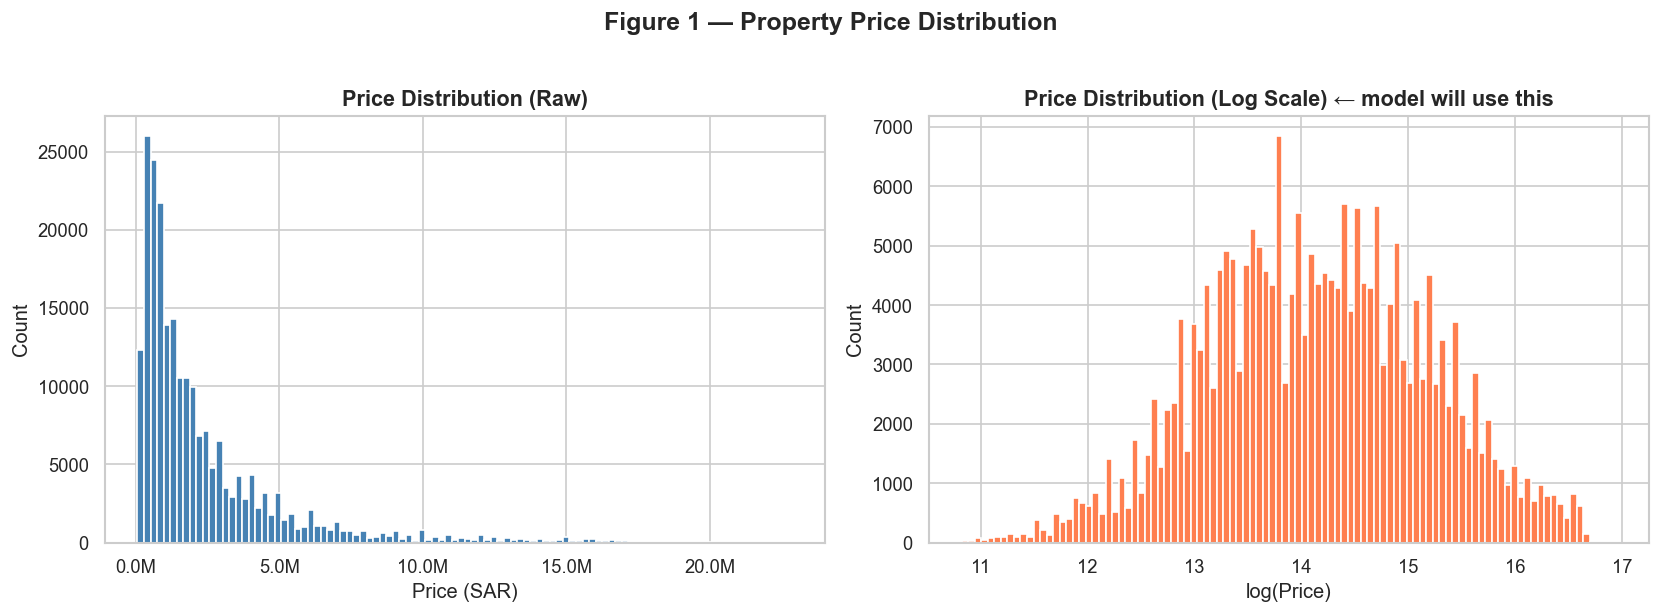

✅ Plot 1 saved


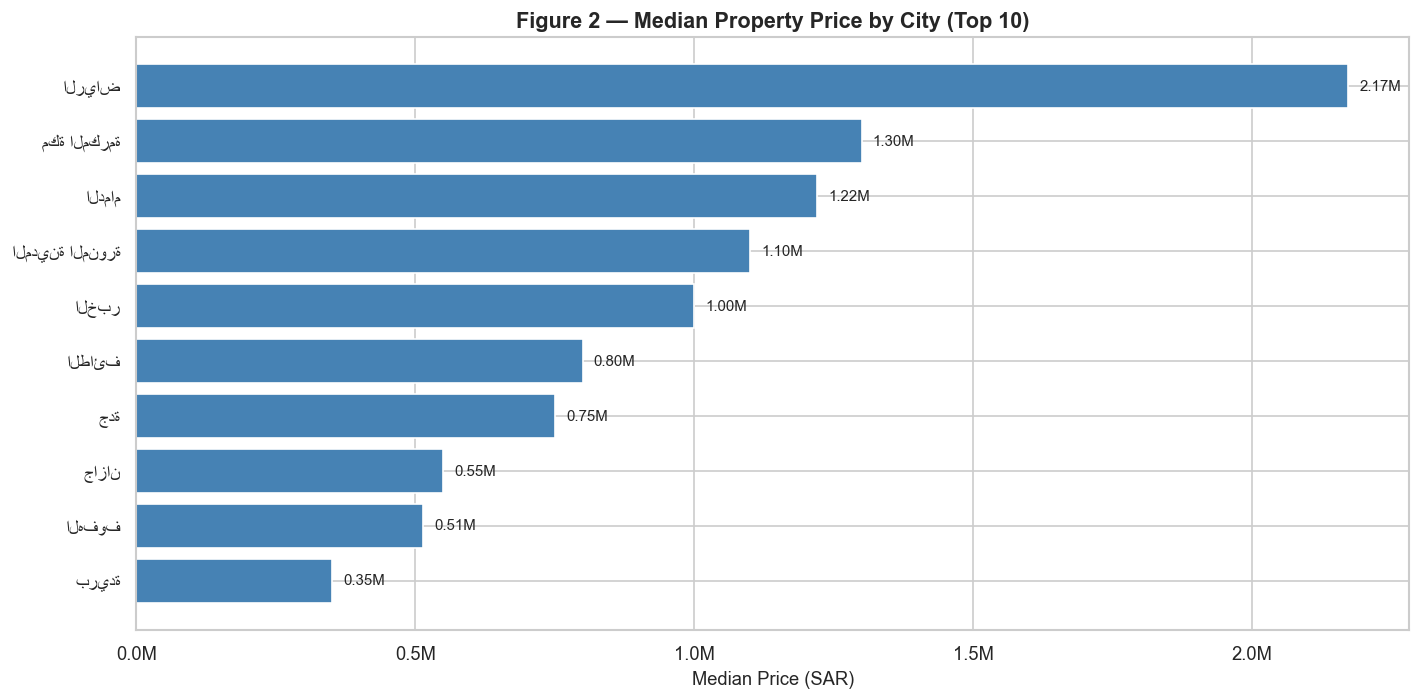

✅ Plot 2 saved


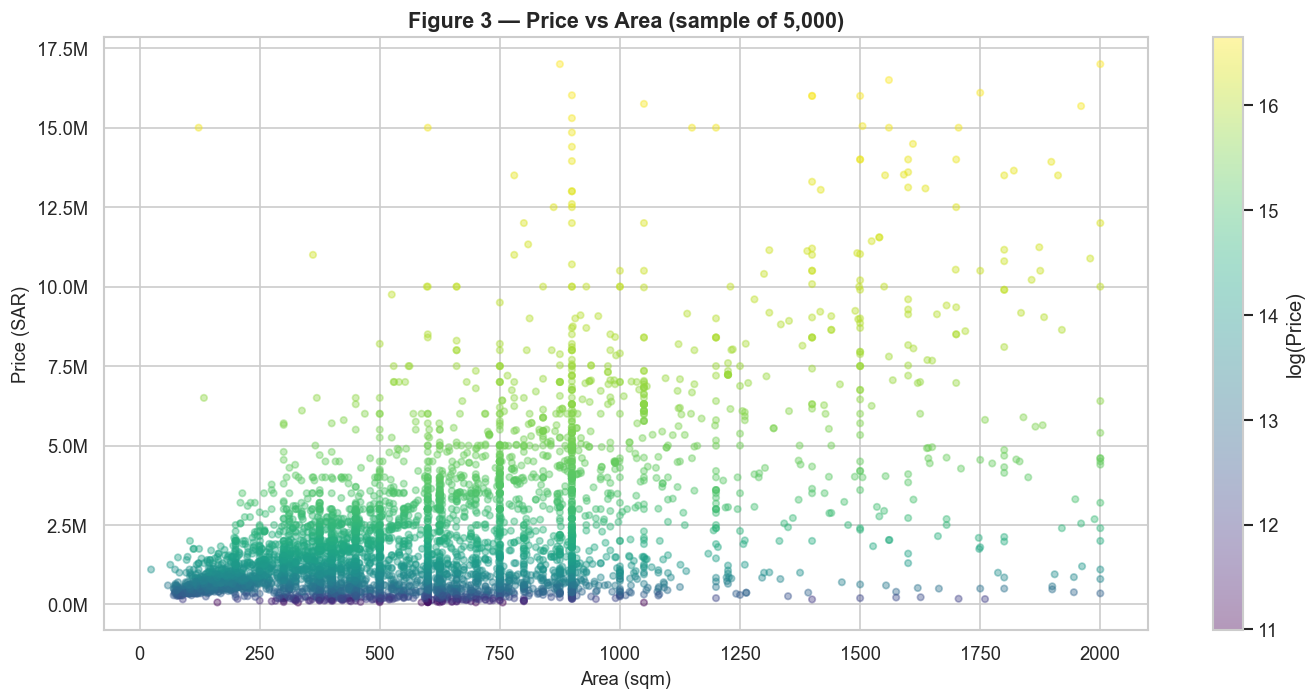

✅ Plot 3 saved


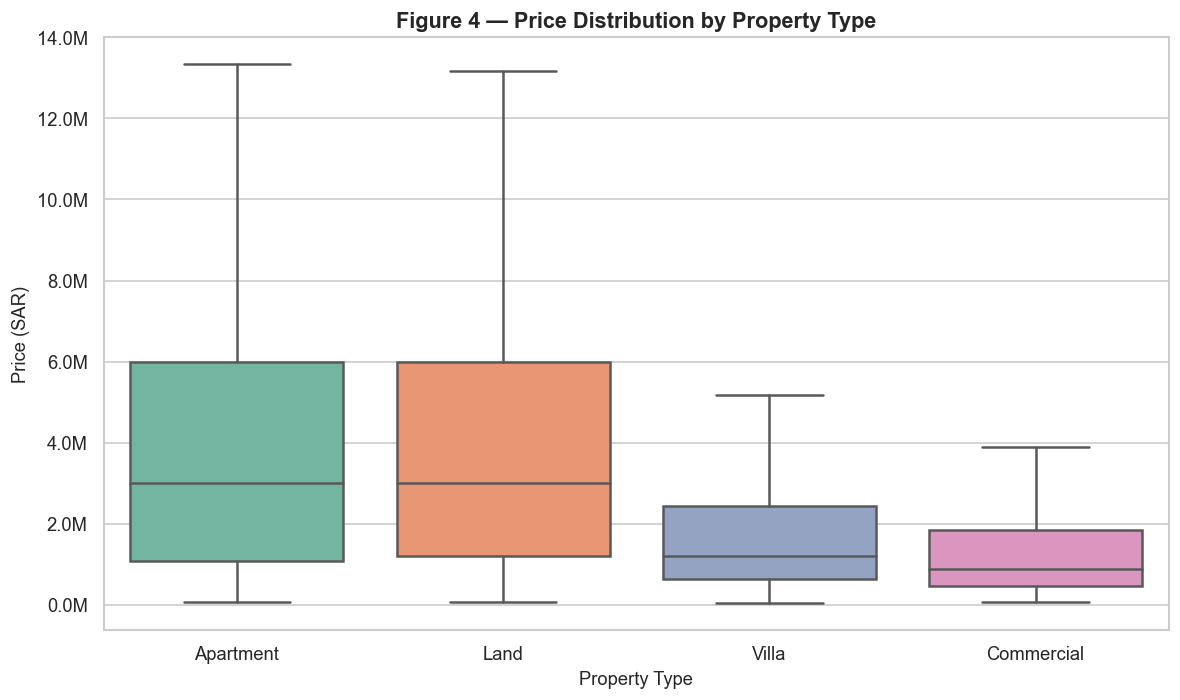

✅ Plot 4 saved


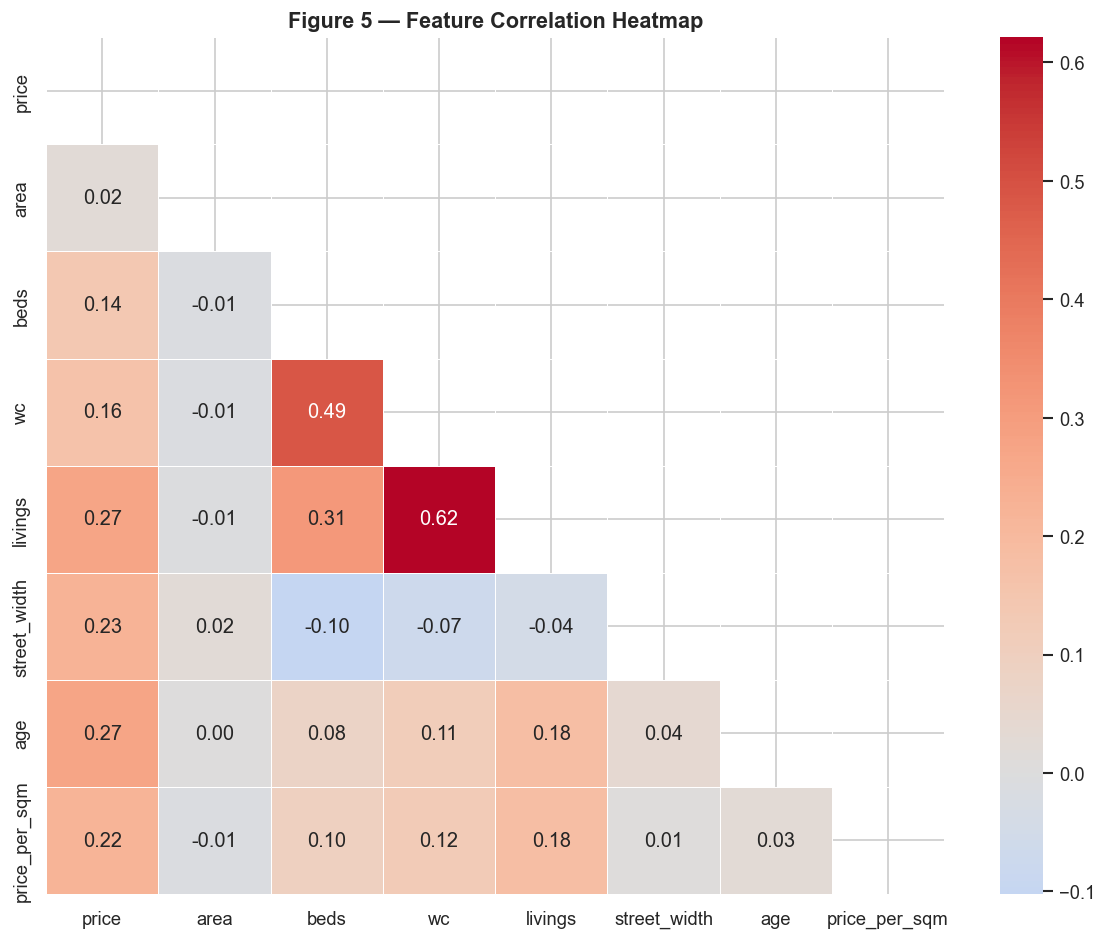

✅ Plot 5 saved


In [11]:


# Global style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

# ============================================================
# PLOT 1: Price Distribution (Log Scale)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw price
axes[0].hist(df_clean['price'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (Raw)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Price (SAR)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Log price
axes[1].hist(df_clean['log_price'], bins=100, color='coral', edgecolor='white')
axes[1].set_title('Price Distribution (Log Scale) ← model will use this', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(Price)')
axes[1].set_ylabel('Count')

plt.suptitle('Figure 1 — Property Price Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot1_price_distribution.png', bbox_inches='tight')
plt.show()
print("✅ Plot 1 saved")

# ============================================================
# PLOT 2: Average Price by City (Top 10)
# ============================================================

top_cities = df_clean['city'].value_counts().head(10).index
city_avg = (df_clean[df_clean['city'].isin(top_cities)]
            .groupby('city')['price']
            .median()
            .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(city_avg.index, city_avg.values, color='steelblue', edgecolor='white')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.set_xlabel('Median Price (SAR)', fontsize=11)
ax.set_title('Figure 2 — Median Property Price by City (Top 10)', fontsize=13, fontweight='bold')

# Add value labels
for bar, val in zip(bars, city_avg.values):
    ax.text(val + 20000, bar.get_y() + bar.get_height()/2,
            f'{val/1e6:.2f}M', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('plot2_price_by_city.png', bbox_inches='tight')
plt.show()
print("✅ Plot 2 saved")

# ============================================================
# PLOT 3: Price vs Area (Scatter) — sample 5000 points
# ============================================================

sample = df_clean[df_clean['area'] <= 2000].sample(5000, random_state=42)

fig, ax = plt.subplots(figsize=(12, 6))
scatter = ax.scatter(
    sample['area'], sample['price'],
    c=sample['log_price'], cmap='viridis',
    alpha=0.4, s=15
)
plt.colorbar(scatter, ax=ax, label='log(Price)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.set_xlabel('Area (sqm)', fontsize=11)
ax.set_ylabel('Price (SAR)', fontsize=11)
ax.set_title('Figure 3 — Price vs Area (sample of 5,000)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('plot3_price_vs_area.png', bbox_inches='tight')
plt.show()
print("✅ Plot 3 saved")

# ============================================================
# PLOT 4: Price by Property Type (Boxplot)
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))
order = df_clean.groupby('property_type')['price'].median().sort_values(ascending=False).index
sns.boxplot(
    data=df_clean, x='property_type', y='price',
    order=order, palette='Set2',
    showfliers=False, ax=ax          # hide outliers for clarity
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.set_xlabel('Property Type', fontsize=11)
ax.set_ylabel('Price (SAR)', fontsize=11)
ax.set_title('Figure 4 — Price Distribution by Property Type', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('plot4_price_by_type.png', bbox_inches='tight')
plt.show()
print("✅ Plot 4 saved")

# ============================================================
# PLOT 5: Correlation Heatmap
# ============================================================

numeric_cols = ['price', 'area', 'beds', 'wc', 'livings',
                'street_width', 'age', 'price_per_sqm']
corr = df_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))   # hide upper triangle
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, ax=ax
)
ax.set_title('Figure 5 — Feature Correlation Heatmap', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('plot5_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print("✅ Plot 5 saved")



## 5. Modeling

In [12]:

# ------------------------------------------------------------
# STEP 1: Prepare Features
# ------------------------------------------------------------

df_model = df_clean.copy()

# Fill missing numeric values with median
num_cols = ['beds', 'livings', 'wc', 'street_width', 'age', 'furnished', 'ac', 'ketchen']
for col in num_cols:
    df_model[col] = df_model[col].fillna(df_model[col].median())

# Fill missing lat/lng with city median
df_model['lat'] = df_model.groupby('city')['lat'].transform(lambda x: x.fillna(x.median()))
df_model['lng'] = df_model.groupby('city')['lng'].transform(lambda x: x.fillna(x.median()))

# Encode categorical columns (city, district, property_type)
le_city     = LabelEncoder()
le_district = LabelEncoder()
le_type     = LabelEncoder()

df_model['city_enc']     = le_city.fit_transform(df_model['city'].astype(str))
df_model['district_enc'] = le_district.fit_transform(df_model['district'].astype(str))
df_model['type_enc']     = le_type.fit_transform(df_model['property_type'].astype(str))

# ------------------------------------------------------------
# STEP 2: Define Features & Target
# ------------------------------------------------------------

FEATURES = [
    'area', 'beds', 'livings', 'wc', 'street_width', 'age',
    'furnished', 'ac', 'ketchen',
    'lat', 'lng',
    'city_enc', 'district_enc', 'type_enc'
]

X = df_model[FEATURES]
y = df_model['log_price']   # predicting log price

# ------------------------------------------------------------
# STEP 3: Train / Test Split (80/20)
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"✅ Data Split Done")
print(f"   Training rows : {X_train.shape[0]:,}")
print(f"   Testing rows  : {X_test.shape[0]:,}")

# ------------------------------------------------------------
# STEP 4: Train XGBoost Model
# ------------------------------------------------------------

model = xgb.XGBRegressor(
    n_estimators     = 500,
    learning_rate    = 0.05,
    max_depth        = 8,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    n_jobs           = -1,       # use all CPU cores
    early_stopping_rounds = 30,
    eval_metric      = 'rmse'
)

print("\n⏳ Training XGBoost... (may take 1-2 minutes)")

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50    # print progress every 50 trees
)

print("\n✅ Training Complete!")

# ------------------------------------------------------------
# STEP 5: Evaluate
# ------------------------------------------------------------

y_pred_log  = model.predict(X_test)

# Convert back from log to real SAR prices
y_pred_real = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)

rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mae  = mean_absolute_error(y_test_real, y_pred_real)
r2   = r2_score(y_test_real, y_pred_real)

# R² on log scale (more reliable metric)
r2_log = r2_score(y_test, y_pred_log)

print("\n" + "="*45)
print("         MODEL PERFORMANCE RESULTS")
print("="*45)
print(f"  R² Score (log scale)  : {r2_log:.4f}")
print(f"  R² Score (SAR)        : {r2:.4f}")
print(f"  MAE                   : {mae:,.0f} SAR")
print(f"  RMSE                  : {rmse:,.0f} SAR")
print("="*45)

# ------------------------------------------------------------
# STEP 6: Save Model & Encoders
# ------------------------------------------------------------

import os
os.makedirs('models', exist_ok=True)

joblib.dump(model,      'models/xgb_model.pkl')
joblib.dump(le_city,    'models/le_city.pkl')
joblib.dump(le_district,'models/le_district.pkl')
joblib.dump(le_type,    'models/le_type.pkl')
joblib.dump(FEATURES,   'models/features.pkl')

print("\n✅ Model & Encoders saved to /models/")

✅ Data Split Done
   Training rows : 176,984
   Testing rows  : 44,247

⏳ Training XGBoost... (may take 1-2 minutes)
[0]	validation_0-rmse:1.00274
[50]	validation_0-rmse:0.47389
[100]	validation_0-rmse:0.44396
[150]	validation_0-rmse:0.43594
[200]	validation_0-rmse:0.43080
[250]	validation_0-rmse:0.42774
[300]	validation_0-rmse:0.42483
[350]	validation_0-rmse:0.42308
[400]	validation_0-rmse:0.42107
[450]	validation_0-rmse:0.41960
[499]	validation_0-rmse:0.41837

✅ Training Complete!

         MODEL PERFORMANCE RESULTS
  R² Score (log scale)  : 0.8382
  R² Score (SAR)        : 0.8199
  MAE                   : 499,465 SAR
  RMSE                  : 1,132,497 SAR

✅ Model & Encoders saved to /models/


In [13]:
# ============================================================
# IMPROVE: Retrain with more trees + better params
# ============================================================

model2 = xgb.XGBRegressor(
    n_estimators          = 1000,
    learning_rate         = 0.05,
    max_depth             = 8,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    min_child_weight      = 5,      # prevents overfitting
    gamma                 = 0.1,    # prevents overfitting
    random_state          = 42,
    n_jobs                = -1,
    early_stopping_rounds = 50,     # stop if no improvement for 50 rounds
    eval_metric           = 'rmse'
)

print("⏳ Retraining with 1000 trees + early stopping...")

model2.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

# Evaluate
y_pred2     = model2.predict(X_test)
y_pred_real2 = np.expm1(y_pred2)

r2_log2 = r2_score(y_test, y_pred2)
r2_2    = r2_score(y_test_real, y_pred_real2)
mae2    = mean_absolute_error(y_test_real, y_pred_real2)
rmse2   = np.sqrt(mean_squared_error(y_test_real, y_pred_real2))

print("\n" + "="*45)
print("      IMPROVED MODEL PERFORMANCE")
print("="*45)
print(f"  Best iteration        : {model2.best_iteration}")
print(f"  R² Score (log scale)  : {r2_log2:.4f}")
print(f"  R² Score (SAR)        : {r2_2:.4f}")
print(f"  MAE                   : {mae2:,.0f} SAR")
print(f"  RMSE                  : {rmse2:,.0f} SAR")
print("="*45)

# Save improved model
joblib.dump(model2, 'models/xgb_model.pkl')
print("\n✅ Improved model saved!")

⏳ Retraining with 1000 trees + early stopping...


[0]	validation_0-rmse:1.00274
[100]	validation_0-rmse:0.44423
[200]	validation_0-rmse:0.43121
[300]	validation_0-rmse:0.42532
[400]	validation_0-rmse:0.42200
[500]	validation_0-rmse:0.41922
[600]	validation_0-rmse:0.41749
[700]	validation_0-rmse:0.41620
[800]	validation_0-rmse:0.41504
[900]	validation_0-rmse:0.41435
[999]	validation_0-rmse:0.41352

      IMPROVED MODEL PERFORMANCE
  Best iteration        : 999
  R² Score (log scale)  : 0.8419
  R² Score (SAR)        : 0.8282
  MAE                   : 479,595 SAR
  RMSE                  : 1,106,144 SAR

✅ Improved model saved!


## 6. Evaluation


⏳ Calculating SHAP values... (takes ~1 min)
✅ SHAP values calculated!


C:\Users\fadra\AppData\Local\Temp\ipykernel_12020\144876808.py:28: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


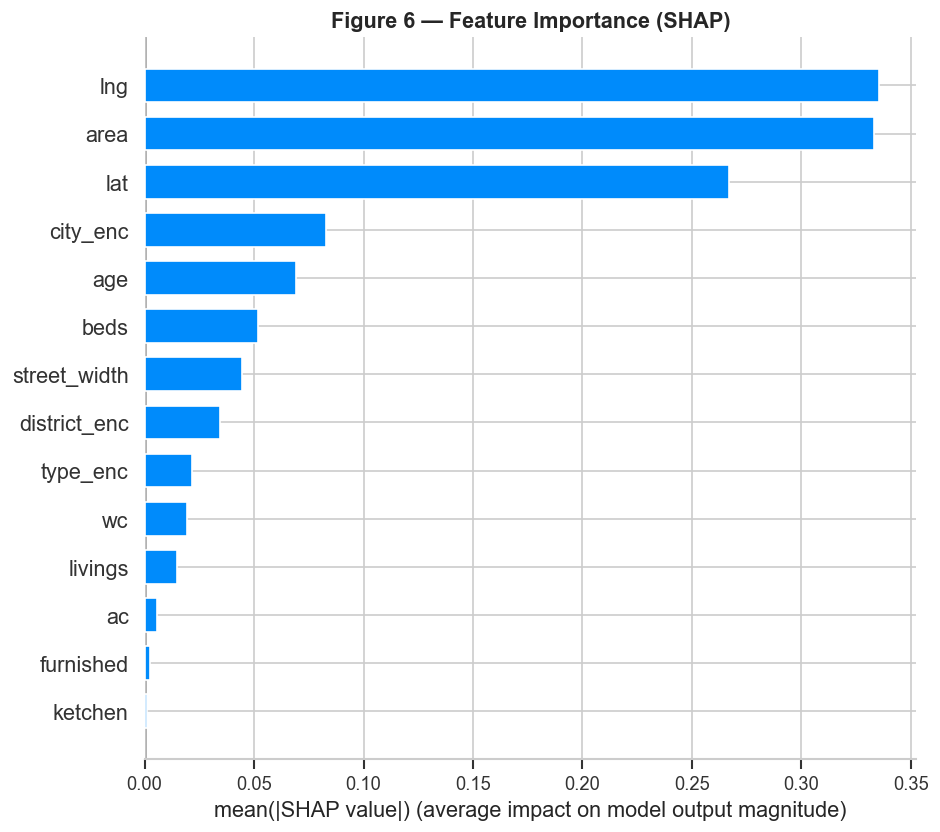

✅ Plot 6 saved


C:\Users\fadra\AppData\Local\Temp\ipykernel_12020\144876808.py:43: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


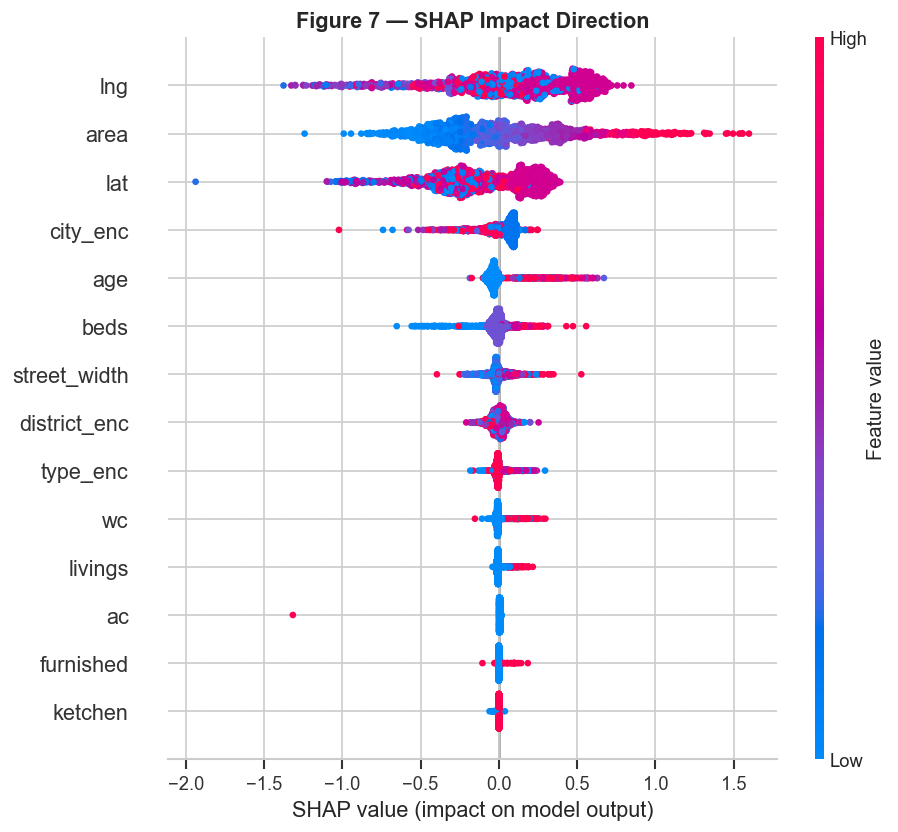

✅ Plot 7 saved

📊 Feature Importance Ranking:
  lng                0.3357
  area               0.3331
  lat                0.2669
  city_enc           0.0828
  age                0.0690
  beds               0.0517
  street_width       0.0444
  district_enc       0.0344
  type_enc           0.0218
  wc                 0.0192
  livings            0.0149
  ac                 0.0056
  furnished          0.0024
  ketchen            0.0013


In [14]:
# ============================================================
# PHASE 4: SHAP FEATURE IMPORTANCE
# ============================================================


print("⏳ Calculating SHAP values... (takes ~1 min)")

# Use a sample of 2000 rows (SHAP is slow on 200k rows)
X_sample = X_test.sample(2000, random_state=42)

# Create SHAP explainer
explainer   = shap.TreeExplainer(model2)
shap_values = explainer.shap_values(X_sample)

print("✅ SHAP values calculated!")

# ------------------------------------------------------------
# PLOT 1: Feature Importance Bar Chart
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values, X_sample,
    plot_type="bar",
    show=False
)
plt.title("Figure 6 — Feature Importance (SHAP)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot6_shap_importance.png', bbox_inches='tight')
plt.show()
print("✅ Plot 6 saved")

# ------------------------------------------------------------
# PLOT 2: SHAP Beeswarm (shows direction of impact)
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_sample,
    show=False
)
plt.title("Figure 7 — SHAP Impact Direction", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot7_shap_beeswarm.png', bbox_inches='tight')
plt.show()
print("✅ Plot 7 saved")

# ------------------------------------------------------------
# Print Top Features as a clean table
# ------------------------------------------------------------

feature_importance = pd.DataFrame({
    'Feature'   : FEATURES,
    'Importance': np.abs(shap_values).mean(axis=0)
}).sort_values('Importance', ascending=False)

print("\n📊 Feature Importance Ranking:")
print("="*35)
for i, row in feature_importance.iterrows():
    print(f"  {row['Feature']:<18} {row['Importance']:.4f}")

In [15]:


# 1. Create the 'app' folder if it doesn't exist yet
os.makedirs('app', exist_ok=True)

# 2. Now extract your lists
cities_list = sorted(df_clean['city'].dropna().unique().tolist())
districts_list = sorted(df_clean['district'].dropna().unique().tolist())

# 3. Save your JSON files safely
with open('app/cities.json', 'w', encoding='utf-8') as f:
    json.dump(cities_list, f, ensure_ascii=False)

with open('app/districts.json', 'w', encoding='utf-8') as f:
    json.dump(districts_list, f, ensure_ascii=False)

## encoding with new sklearn version

In [16]:


# Redo the encoding with new sklearn version
le_city     = LabelEncoder()
le_district = LabelEncoder()
le_type     = LabelEncoder()

df_model['city_enc']     = le_city.fit_transform(df_model['city'].astype(str))
df_model['district_enc'] = le_district.fit_transform(df_model['district'].astype(str))
df_model['type_enc']     = le_type.fit_transform(df_model['property_type'].astype(str))

# Resave encoders with new sklearn version
os.makedirs('models', exist_ok=True)
joblib.dump(le_city,     'models/le_city.pkl')
joblib.dump(le_district, 'models/le_district.pkl')
joblib.dump(le_type,     'models/le_type.pkl')

print("✅ Encoders resaved with new sklearn version!")
import sklearn
print(f"sklearn version: {sklearn.__version__}")

✅ Encoders resaved with new sklearn version!
sklearn version: 1.3.0


In [17]:
result = subprocess.run(
    ['pip', 'install', 'scikit-learn==1.5.2', '--upgrade', '--force-reinstall'],
    capture_output=True, text=True
)
print(result.stdout[-500:])
print(result.stderr[-200:])

- 4/5 [scikit-learn]
   -------------------------------- ------- 4/5 [scikit-learn]
   -------------------------------- ------- 4/5 [scikit-learn]
   -------------------------------- ------- 4/5 [scikit-learn]
   -------------------------------- ------- 4/5 [scikit-learn]
   -------------------------------- ------- 4/5 [scikit-learn]
   ---------------------------------------- 5/5 [scikit-learn]


cy conflicts.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.
tables 3.8.0 requires blosc2~=2.0.0, which is not installed.
tables 3.8.0 requires cython>=0.29.21, which is not installed.



In [7]:
from sklearn.preprocessing import LabelEncoder
import joblib, os
import sklearn
print(f"sklearn version: {sklearn.__version__}")

le_city     = LabelEncoder()
le_district = LabelEncoder()
le_type     = LabelEncoder()

df_model['city_enc']     = le_city.fit_transform(df_model['city'].astype(str))
df_model['district_enc'] = le_district.fit_transform(df_model['district'].astype(str))
df_model['type_enc']     = le_type.fit_transform(df_model['property_type'].astype(str))

os.makedirs('models', exist_ok=True)
joblib.dump(le_city,     'models/le_city.pkl')
joblib.dump(le_district, 'models/le_district.pkl')
joblib.dump(le_type,     'models/le_type.pkl')

print("✅ Encoders resaved!")

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [9]:
# ============================================================
# FINAL: Verify saved files
# ============================================================
import os

files_to_check = [
    'models/xgb_model.pkl',
    'models/le_city.pkl', 
    'models/le_district.pkl',
    'models/le_type.pkl',
    'models/features.pkl',
    'app/cities.json',
    'app/districts.json'
]

print("📦 Checking saved files:")
for f in files_to_check:
    exists = "✅" if os.path.exists(f) else "❌ MISSING"
    size   = f"{os.path.getsize(f)/1024/1024:.1f} MB" if os.path.exists(f) else ""
    print(f"  {exists} {f} {size}")

📦 Checking saved files:
  ✅ models/xgb_model.pkl 9.5 MB
  ✅ models/le_city.pkl 0.0 MB
  ✅ models/le_district.pkl 0.0 MB
  ✅ models/le_type.pkl 0.0 MB
  ✅ models/features.pkl 0.0 MB
  ✅ app/cities.json 0.0 MB
  ✅ app/districts.json 0.0 MB
